In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from myDataset import *
from ArchitectureMethods import *
from MetricMethods import *

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.cpu.manual_seed = seed
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Sets current directory as ws
print(os.getcwd())
os.chdir('..')
print(os.getcwd())
# Checks if device is available (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

train_dataset = myDataset(directory = "DATASET/train", transform = train_transform)
val_dataset = myDataset(directory = "DATASET/validation", transform = val_transform)
test_dataset = myDataset(directory = "DATASET/test", transform = test_transform)

print(f'Train set length: '+ str(len(train_dataset)))
print(f'Test set length: '+ str(len(val_dataset)))
print(f'Validation set length: '+ str(len(test_dataset)))

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle = True, num_workers = 8)
val_loader = DataLoader(val_dataset, batch_size = 16, shuffle = False, num_workers = 8)
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False, num_workers = 8)



/user/HS401/ob00564/Documents/COM3001/CK+/Transfer Learning
/user/HS401/ob00564/Documents/COM3001/CK+
cuda
Train set length: 720
Test set length: 89
Validation set length: 93


In [3]:
sorted_emotion_counts = train_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = val_dataset.getNoImagesInClass()
print(sorted_emotion_counts)
sorted_emotion_counts = test_dataset.getNoImagesInClass()
print(sorted_emotion_counts)

{'0': 36, '1': 47, '2': 20, '3': 55, '4': 22, '5': 66, '6': 474}
{'0': 4, '1': 6, '2': 2, '3': 7, '4': 3, '5': 8, '6': 59}
{'0': 5, '1': 6, '2': 3, '3': 7, '4': 3, '5': 9, '6': 60}


In [4]:
# @title Importing ResNet34 model, using DEFAULT weights
import torchvision.models as models
emotionTotal = 7
myModel = models.mobilenet_v2(weights = 'DEFAULT')
myModel.classifier = torch.nn.Linear(in_features=1280, out_features= 7)
print(myModel)
# Freeze all layers
for param in myModel.parameters():
    param.requires_grad = False

for param in myModel.classifier.parameters():
    param.requires_grad = True

# Unfreeze 16th, 17th, 18th layers
for id in range(16,19):
    for param in myModel.features[id].parameters():
        param.requires_grad = True
            
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
myModel.to(device)
print(device)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [6]:
import copy
# @title Training Loop
from tqdm import tqdm
# Loss function 
criterion = nn.CrossEntropyLoss()

# Optimizer
# optimizer = optim.SGD(myModel.parameters(), lr = 0.0001, momentum=0.9, weight_decay= 0.0001)
optimizer = optim.Adam(myModel.parameters(), lr = 0.00001, weight_decay=0.01)

train_losses, val_losses, train_accuracy, val_accuracy = train(myModel, device, train_loader, val_loader, optimizer, None, 100, criterion, 'CK+/Transfer Learning/CK+ MobileNetV2.pth')
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')



100%|██████████| 45/45 [00:07<00:00,  6.41it/s]


Epoch 1/100, Training Loss: 1.9328, Validation Loss: 1.8910
Epoch 1/100, Training Acc: 13.194444444444445, Validation Accuracy: 18.51851851851852


100%|██████████| 45/45 [00:00<00:00, 52.47it/s]


Epoch 2/100, Training Loss: 1.8369, Validation Loss: 1.8094
Epoch 2/100, Training Acc: 35.97222222222222, Validation Accuracy: 44.44444444444444


100%|██████████| 45/45 [00:00<00:00, 52.95it/s]


...

Epoch 98/100, Training Loss: 0.4164, Validation Loss: 0.5616
Epoch 98/100, Training Acc: 86.38888888888889, Validation Accuracy: 87.5


100%|██████████| 45/45 [00:00<00:00, 50.43it/s]


Epoch 99/100, Training Loss: 0.4258, Validation Loss: 0.5598
Epoch 99/100, Training Acc: 86.38888888888889, Validation Accuracy: 86.45833333333334


100%|██████████| 45/45 [00:00<00:00, 48.39it/s]


Epoch 100/100, Training Loss: 0.4068, Validation Loss: 0.5481
Epoch 100/100, Training Acc: 87.63888888888889, Validation Accuracy: 87.5
Model saved successfully!
Test Loss: 0.6018, Test Accuracy: 80.65%


Test Loss: 0.6018, Test Accuracy: 80.65%


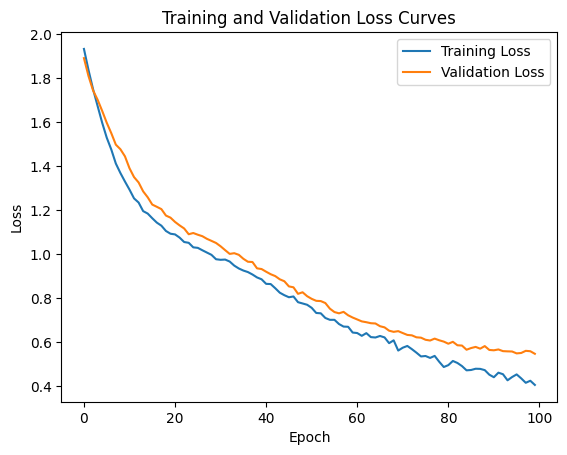

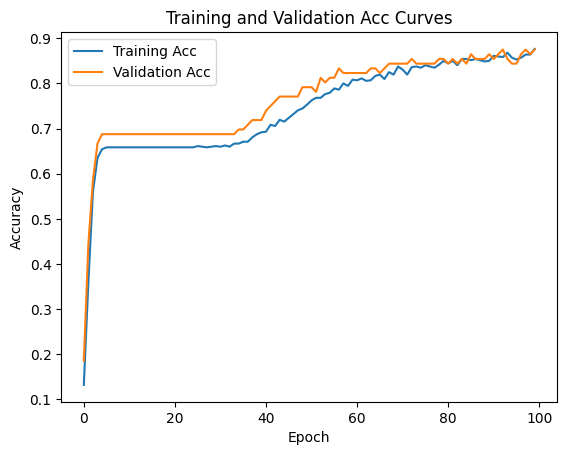

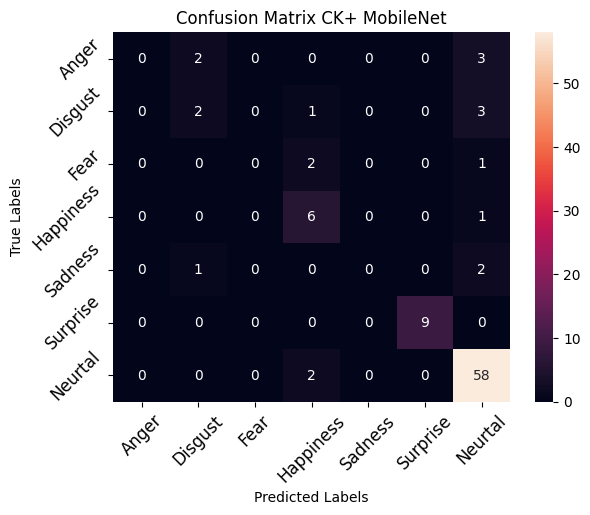

              precision    recall  f1-score   support

       Anger     0.0000    0.0000    0.0000         5
     Disgust     0.4000    0.3333    0.3636         6
        Fear     0.0000    0.0000    0.0000         3
   Happiness     0.5455    0.8571    0.6667         7
     Sadness     0.0000    0.0000    0.0000         3
    Surprise     1.0000    1.0000    1.0000         9
     Neurtal     0.8529    0.9667    0.9062        60

    accuracy                         0.8065        93
   macro avg     0.3998    0.4510    0.4195        93
weighted avg     0.7139    0.8065    0.7551        93



/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/user/HS401/ob00564/Documents/COM3001/myenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [8]:
y_true, y_pred, y_score = test(myModel, device, criterion, test_loader, 'Test')
lossPlot(train_losses, val_losses)
accuracyPlot(train_accuracy, val_accuracy)
confusionMatrixPlot(y_true, y_pred, 'CK+ MobileNet')